### Plots for marker gene annotation

In [ ]:
# eval "$(conda shell.bash hook)"
# conda init
# conda activate /work/islet_cartography_scrna/scrna_cartography_py_analysis
# python -m ipykernel install --user --name scrna_cartography_py_analysis --display-name "py_analysis"

In [1]:
# Path and system utilities
import os                    # Operating system interface
import sys                   # System-specific parameters and functions
import glob                  # File pattern matching
from pathlib import Path     # Object-oriented filesystem paths
from pyhere import here      # Reproducible project paths

# Single-cell data handling
import anndata as ad            # Core data structure for single-cell data
import scanpy as sc          # Analysis and visualization of single-cell data

# dataframes
import pandas as pd
import numpy as np
# Micellaneous utilities
import warnings              # Suppress or manage warnings

# Data visualization
import seaborn as sns        # Statistical data visualization
import matplotlib.pyplot as plt  # Plotting interface
import matplotlib            # Base matplotlib functionality
from matplotlib.backends.backend_pdf import PdfPages  # Save plots to multi-page PDFs
import tol_colors            # colors

# Custom modules and functions
sys.path.append(str(here('scripts/misc')))  # Add custom script path to system
import my_anndata as ma                    # Custom AnnData utilities
import misc as mi
import diff_genes as dg

In [2]:
# Paths
base_dir = str(here('data/annotate/'))
plot_dir = os.path.join(base_dir, 'plot') 
files_dir = os.path.join(base_dir, 'files') 
diffg_dir = os.path.join(base_dir, 'dg_onevsother') 

anndata_dir = str(here('data/anndata/'))

In [ ]:
mi.create_directories(os.path.join(base_dir, 'dg_onevsother'))
mi.create_directories(os.path.join(diffg_dir, 'summary_cell_cutoffs'))

#### Colors for cell types

In [ ]:
# Cell type colors
manual_anno_colors = {
    'acinar': '#c5b0d5',
    'acinar_reg_plus': '#FFCD01',
    'alpha': '#1f77b4',
    'beta': '#ff0000',
    'cycling': '#aec7e8',
    'delta': '#895129',
    'ductal': '#FF46A2',
    'ductal_mucin': '#F7B6D2',
    'endmt_early': '#ae0000',
    'endmt_late': '#44BDF8',
    'endothelial_islet': '#D844F8',
    'epsilon': '#BCF646',
    'gamma': '#FFBB78',
    'mast': '#0000FF',
    'myeloid': '#ee7733',
    'schwann': '#BCBD22',
    'stellate_activated': '#64F844',
    'stellate_quiescent': '#9467BD'
}

#### Plotting settings

In [96]:
# Plotting theme
sc.settings.set_figure_params(
    dpi=150,
    figsize=(5,5),
    frameon=False
)
sc.settings.figdir = plot_dir

In [ ]:
markers = {
    "stellate_quiescent": [
        "RGS5","FABP4","CYGB","PLIN2","ADIRF"
    ],
    "stellate_activated": [
        "ACTA2","MMP3","VCAN","AEBP1","TIMP1"
    ],
    "epsilon": ["GHRL","PHGR1"],
    "beta": ["INS","IAPP","G6PC2"],
    "alpha": ["GCG","ARX","MAFB"],
    "delta": ["SST","HHEX","RBP4"],
    "gamma": ["PPY","ARX","ETV1"],
    "endmt" : ["S100A4", "APOE", "TGFBI", "C3AR1", "LGALS3", "DDR2", "ACTA2"],
    "acinar": ["PRSS1","PRSS2","AMY2B"],
    "acinar_reg_plus" : ["REG3A", "REG3G", "REG1B", "REG1A"],
    "schwann": ["SOX10","S100B","CRYAB"],
    "mast": ["TPSAB1","TPSB2","CPA3","KIT"],
    "cycling": ["TOP2A","MKI67"],
    "ductal": ["KRT19","SOX9","HNF1B"],
    "ductal_mucin": [
        "MUC5B","ERN2","CYP2C18","MYO7B","DMBT1",
        "TFF1","TFF2","TFF3", "CYP2C18", "MYO7B", "DMBT1"
    ],
    "myeloid": ["CD68","HLA-DRA","PTPRC","CSF1R","LYZ","ITGAM"],
    "endothelial": [
        "PLVAP","CLDN5","PECAM1","VWF","CDH5","KDR","FLT1"
    ],
    "endothelial_islet": [
        "ACE","PASK","F2RL3","ESM1","CXCR4","ACKR3","UNC5B",
        "LAMA4","CREM","COL13A1","NKX2-3","ANGPTL2","THBS1"]
}

In [13]:
markers = {
    "stellate_quiescent": [
        "RGS5","FABP4","CYGB","PLIN2","ADIRF"
    ],
    "stellate_activated": [
        "ACTA2","MMP3","VCAN","AEBP1","TIMP1"
    ],
    "epsilon": ["GHRL","PHGR1"],
    "beta": ["INS","IAPP","G6PC2", "PDX1", "MAFA", "NKX6-1"],
    "alpha": ["GCG","ARX","MAFB", "TTR", "PAX6", "GC"],
    "delta": ["SST","HHEX","RBP4"],
    "gamma": ["PPY","ARX","ETV1"],
    "endmt" : ["S100A4", "APOE", "TGFBI", "C3AR1", "LGALS3", "DDR2", "ACTA2", "GAPDH", "COL3A1", "HIF1A", "MYC"],
    "endmt_mid": [
    "TNFRSF21", "AMOTL2", "BACE2", "CLU", "CPXM2", "CRIM1", "CTNNAL1",
    "DEPP1", "DHRS3", "ID2", "IL1R1", "IL1RL1", "INSIG2", "LEPR", "LIFR",
    "MLLT1", "MPP3", "MYL12B", "NRG1", "OAZ1", "PAPSS2", "PGRMC2",
    "PTGS2", "PTTG1IP", "RHOB", "SAT1", "SKIL", "SLC41A3", "SPINT2",
    "SRPX", "THBS1", "TMEM120A", "ZDHHC2", "ALDH1A1", "BMP2", "BMP4",
    "BMPER", "BPGM", "FOXC1", "HHIP", "METRNL", "S100A13", "SLC16A5",
    "SMAD6", "COPZ2", "C1R", "C1S", "CALU", "CGNL1", "COL8A1",
    "CYBRD1", "FN1", "FTH1", "LTBP2", "LTBP4", "MEDAG", "MGP",
    "MT1E", "OMD", "PCDH7", "RCAN3", "TIMP1", "COL8A2", "SFRP5",
    "CP", "EFEMP1", "FGF2", "IGFBP3", "IRF6", "SERPINE1", "TMEM98",
    "PTPRF", "SERPINE2"
],
    "acinar": ["PRSS1","PRSS2","AMY2B"],
    "acinar_reg_plus" : ["REG3A", "REG3G", "REG1B", "REG1A"],
    "schwann": ["SOX10","S100B","CRYAB", "PMP22"],
    "mast": ["TPSAB1","TPSB2","CPA3","KIT"],
    "cycling": ["TOP2A","MKI67"],
    "ductal": ["KRT19","SOX9","HNF1B"],
    "ductal_mucin": [
        "MUC5B","ERN2","CYP2C18","MYO7B","DMBT1",
        "TFF1","TFF2","TFF3", "MUC1"
    ],
    "myeloid": ["CD68","HLA-DRA","PTPRC","CSF1R","LYZ","ITGAM"],
    "endothelial_islet": [
        "ACE","PASK","F2RL3","ESM1","CXCR4","ACKR3","UNC5B",
        "LAMA4","CREM","COL13A1","NKX2-3","ANGPTL2"],
}

In [36]:
markers = {
    "acinar": ["PRSS1", "PRSS2", "CPA1"],
    "acinar_reg_plus": ["REG3A", "REG3G", "REG1B"],
    "alpha": ["GCG", "TTR", "MAFB"],
    "beta": ["INS", "IAPP", "INS-IGF2"],
    "cycling": ["TOP2A", "MKI67", "CCNB1"],
    "delta": ["SST", "HHEX", "LY6H"],
    "ductal": ["KRT19", "CFTR", "HNF1B"],
    "ductal_mucin": ["MUC1", "TFF1", "TFF2"],
    "endmt": ["COL3A1", "DDR2", "HIF1A"],
    "endothelial": ["PECAM1", "PLVAP", "FLT1"],
    "endothelial_islet": ["PASK", "ESM1", "LAMA4"],
    "epsilon": ["GHRL", "PHGR1", "RBP4"],
    "gamma": ["PPY", "ARX", "ETV1"],
    "mast": ["S100A4", "RGS10", "LTC4S"],
    "myeloid": ["LYZ", "HLA-DRA", "CD68"],
    "schwann" : ["CRYAB", "S100B", "PMP22"],
    "stellate_a": ["TIMP1", "COL1A2", "VCAN"],
    "stellate_q": ["RGS5", "FABP4", "ADIRF"]
}

In [37]:
marker_genes = []
for cell, x in markers.items():
    marker_genes += x

In [5]:
# Adata object
adata = ad.read_h5ad(os.path.join(anndata_dir, "AG_combined.h5ad"))

#### Percent of cells express

#### Mean gene expression per group

In [29]:
pct_genes_df = dg.compute_pct_expressing(
    ad=adata, 
    cluster_key="manual_annotation", workers = 60)
pct_genes_df.to_csv(os.path.join(files_dir, "genes_pct_expressed.csv"), index="gene_symbol")

In [38]:
genedf = sc.get.obs_df(adata, keys=["manual_annotation", *marker_genes])
grouped = genedf.groupby("manual_annotation", observed=True)
mean, var = grouped.mean(), grouped.var()

In [39]:
mean.to_csv(os.path.join(files_dir, "mean_marker_expression.csv"), index="manual_annotation")
var.to_csv(os.path.join(files_dir, "var_marker_expression.csv"), index="manual_annotation")

In [ ]:
sc.tl.dendrogram(adata, groupby="manual_annotation", use_rep='X_latent_1')
dp = sc.pl.dotplot(adata, markers, 'manual_annotation', standard_scale = "var", cmap=tol_colors.iridescent, dendrogram= True, return_fig=True)
dp.add_totals().style(dot_edge_color='black', dot_edge_lw=0.5).show()

In [ ]:
# Umap with annotation
sc.pl.umap(
    adata,
    color='manual_annotation',
    palette=manual_anno_colors,
    legend_fontsize=5,
    size=1,
    show=False  
)

# Rasterize all scatter points (collections)
ax = plt.gca()
for coll in ax.collections:
    coll.set_rasterized(True)

# Save PDF
plt.savefig(
    os.path.join(sc.settings.figdir, "umap_manual_annotation.pdf"),
    bbox_inches="tight", 
    dpi = 300
)
plt.close()

Diffenretial gene expression

In [ ]:
sample_key = 'ic_id_platform_adjusted_sample'
cluster_key = 'manual_annotation' 
layer = 'counts'
workers = 60
n_cells = 1000
minimum_cells = 10
cutoffs = range(minimum_cells, n_cells + 1)

# Compute percent expressing genes once using the cluster_key
pct_genes_df = dg.compute_pct_expressing(
    ad=adata, 
    cluster_key=cluster_key, 
    layer=layer, 
    workers=workers
)

all_results_list = []
summary_list = []

# Loop over each unique cluster in manual_annotation
for cluster_id in adata.obs[cluster_key].unique():

    # Create binary column for current cluster vs others
    col_name = f"{cluster_id}_vs_other"
    adata.obs[col_name] = adata.obs[cluster_key].apply(lambda x: cluster_id if x == cluster_id else 'other')

    # Check if n_cells of x is okay to have atleast 3 replicates 
    counts = (
    adata.obs
    .groupby([sample_key, col_name])
    .size()
    .unstack(fill_value=0))
    
    # Count number of samples at each cutoff
    n_samples_cluster_id = [(counts[cluster_id] >= c).sum() for c in cutoffs]
    n_samples_other = [(counts['other'] >= c).sum() for c in cutoffs]
    summary_df = pd.DataFrame({'min_cells': cutoffs, 'n_samples_cluster_id': n_samples_cluster_id, 'n_samples_other': n_samples_other})

    min_cells = summary_df[((summary_df['n_samples_cluster_id'] >= 3) & (summary_df['n_samples_other'] >=3))]['min_cells'].max()

    # Determine number of cells to use for pseudobulk
    if pd.isna(min_cells) or min_cells < minimum_cells:
        # Skip this cluster because not enough cells
        continue
    elif min_cells < n_cells:
        n_cells_to_use = min_cells
    else:
        n_cells_to_use = n_cells

    # Record final summary for this cluster
    used_summary = pd.DataFrame({
        'cluster': [cluster_id],
        'n_cells_to_use': [n_cells_to_use],
        'n_samples_cluster': [int((counts[cluster_id] >= n_cells_to_use).sum())],
        'n_samples_other': [int((counts['other'] >= n_cells_to_use).sum())]
    })
    summary_list.append(used_summary)
                
        
    # Prepare pseudobulk DESeq object
    pseudo_barcodes, dds = dg.prepare_pseudobulk_deseq_analysis(
        ad=adata,
        n_cells=n_cells_to_use,
        sample_key=sample_key,
        cluster_key=col_name,
        design=f'~ {sample_key} + {col_name}',
        layer=layer,
        func='sum',
        return_all = True,
        workers=workers
    )

    # Save barcodes used for pseudobulk
    pseudo_barcodes.to_csv(os.path.join(diffg_dir, f"pd_barcodes_for_deg_manual_annotation_{cluster_id}_vs_allother.csv"), index_label= "barcode")

    # Define comparison
    comparisons = [(cluster_id, 'other')]

    # Run Wald test
    results_list = [
        dg.diff_genes_two_clusters(
            dds_obj=dds,
            cluster_index=col_name,
            cluster_1=c1,
            cluster_2=c2,
            workers=workers
        ).assign(comparison=f"{cluster_id}_vs_other")
        for c1, c2 in comparisons
    ]

    # Extract results
    all_results = dg.extract_results(
        comparisons=comparisons, 
        results_list=results_list, 
        pct_genes_df=pct_genes_df
    )

    # Save results
    all_results.to_csv(os.path.join(diffg_dir, f"deg_wald_manual_annotation_{cluster_id}_vs_allother.csv"), index_label= "gene_symbol")

    # Append to list
    all_results_list.append(all_results)

# Concatenate all results into a single dataframe
final_results_df = pd.concat(all_results_list, axis=0).reset_index(drop=True)

# save
final_results_df.to_csv(os.path.join(diffg_dir, "deg_wald_manual_annotation_one_vs_allother.csv"), index_label= "gene_symbol")

# Save summary
final_summary_df = pd.concat(summary_list, axis=0).reset_index(drop=True)
final_summary_df.to_csv(os.path.join(diffg_dir, "deg_wald_summary_used_min_cells.csv"), index=False)

#### Diff genes endmt and endothelial

In [ ]:
cluster_key = 'manual_annotation'
sample_key = 'ic_id_platform_adjusted_sample'
design= '~ ic_id_platform_adjusted_sample + manual_annotation'

# subset
adata_sub = adata[adata.obs[cluster_key].isin(["endmt_early", "endmt_late", "endothelial_islet"])].copy()

dds = dg.prepare_pseudobulk_deseq_analysis(ad = adata_sub, 
                                           n_cells = 31,
                                           sample_key = sample_key, 
                                           cluster_key = cluster_key, 
                                           design = design, 
                                           layer='counts', 
                                           func='sum', 
                                           random_state = 100,
                                           workers=60)

comparisons = [("endmt_early", "endothelial_islet"),
               ("endmt_late", "endothelial_islet")]

# Wald test
results_list = [
    dg.diff_genes_two_clusters(dds_obj = dds, cluster_index=cluster_key,
                            cluster_1=c1, cluster_2=c2, workers=60).assign(comparison=f"{c1}_vs_{c2}")
    for c1, c2 in comparisons
]

# Combine all results
all_results = dg.extract_results(comparisons = comparisons, results_list = results_list, pct_genes_df=pct_genes_df)

# Save results
all_results.to_csv(os.path.join(diffg_dir, "deg_wald_endmt_vs_endothelial_islet.csv"), index_label= "gene_symbol")

In [ ]:
adata_sub = adata[adata.obs['manual_annotation'].isin(["endmt_early", "endmt_late", "endothelial_islet"])].copy()


In [80]:
import pyucell as uc

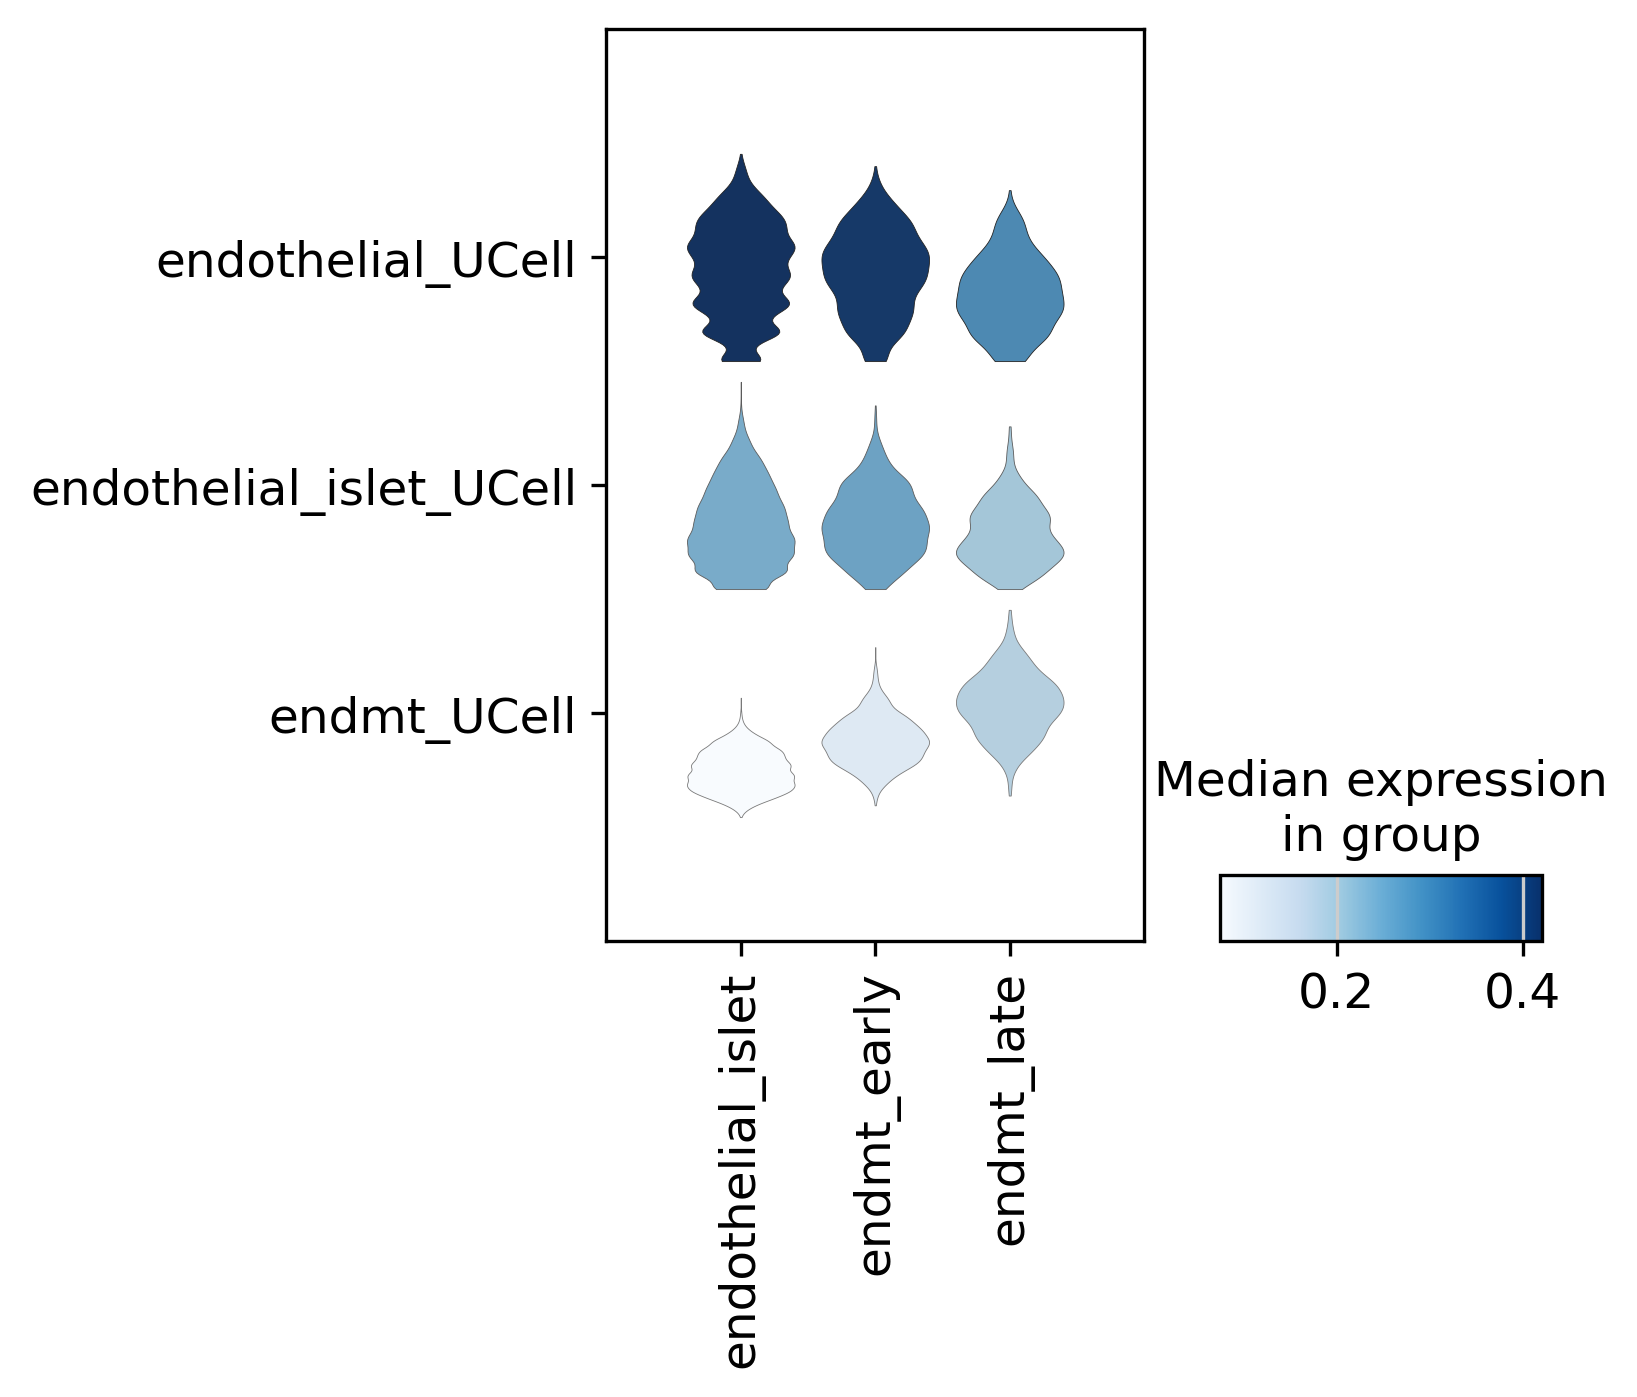

In [101]:
markers = {
    "endothelial": ["PECAM1", "PLVAP", "FLT1"],
    "endmt": ["DEPP1", "APOE", "TGFBI", "COL1A1", "LGALS3", "SNAI2", "TWIST1"]
}


#uc.compute_ucell_scores(adata_sub, signatures=genes)

sc.pl.stacked_violin(adata_sub, var_names=['endothelial_UCell', 'endothelial_islet_UCell', 'endmt_UCell'], figsize=(4,4), groupby='manual_annotation', swap_axes= True, categories_order=["endothelial_islet", "endmt_early", "endmt_late"])

In [90]:
genes = {
    
    "endothelial": ["PLVAP","CLDN5","PECAM1","VWF","CDH5","KDR","FLT1"],
    "endothelial_islet": [
        "ACE","PASK","F2RL3","ESM1","CXCR4","ACKR3","UNC5B",
        "LAMA4","CREM","COL13A1","NKX2-3","ANGPTL2","THBS1"],
    "endmt" : [
    "ABI3BP","ACTA2","ADAM12","ANPEP","APLP1","AREG","BASP1","BDNF","BGN","BMP1",
    "CADM1","CALD1","CALU","CAP2","CAPG","CD44","CD59","CDH11","CDH2","CDH6",
    "COL11A1","COL12A1","COL16A1","COL1A1","COL1A2","COL3A1","COL4A1","COL4A2",
    "COL5A1","COL5A2","COL5A3","COL6A2","COL6A3","COL7A1","COL8A2","COMP","COPA",
    "CRLF1", "CTHRC1","CXCL1","CXCL12","CXCL6", "DAB2","DCN","DKK1",
    "DPYSL3","DST","ECM1","ECM2","EDIL3","EFEMP2","ELN","EMP3","ENO2","FAP","FAS",
    "FBLN1","FBLN2","FBLN5","FBN1","FBN2","FERMT2","FGF2","FLNA","FMOD","FN1",
    "FOXC2","FSTL1","FSTL3","FUCA1","FZD8","GADD45A","GADD45B","GAS1","GEM","GJA1",
    "GLIPR1", "GPC1","GPX7","GREM1","HTRA1","ID2","IGFBP2","IGFBP3",
    "IGFBP4","IL15","IL32","IL6", "INHBA","ITGA2","ITGA5","ITGAV","ITGB1",
    "ITGB3","ITGB5","JUN","LAMA1","LAMA2","LAMA3","LAMC1","LAMC2",
    "LGALS1","LOX","LOXL1","LOXL2","LRP1","LRRC15","LUM","MAGEE1","MATN2","MATN3",
    "MCM7","MEST","MFAP5","MGP","MMP1","MMP14","MMP2","MMP3","MSX1","MXRA5",
    "MYL9","MYLK","NID2","NNMT","NOTCH2","NT5E","NTM","OXTR","PCOLCE","PCOLCE2",
    "PDGFRB","PDLIM4","PFN2","PLAUR","PLOD1","PLOD2","PLOD3","PMEPA1","PMP22",
    "POSTN","PPIB","PRRX1","PRSS2","PTHLH","PTX3","PVR","QSOX1","RGS4","RHOB",
    "SAT1","SCG2","SDC1","SDC4","SERPINE1","SERPINE2","SERPINH1","SFRP1","SFRP4",
    "SGCB","SGCD","SGCG","SLC6A8","SLIT2","SLIT3","SNAI2","SNTB1","SPARC",
    "SPOCK1","SPP1","TAGLN","TFPI2","TGFB1","TGFBI","TGFBR3","TGM2","THBS1",
    "THBS2","THY1","TIMP1","TIMP3","TNC","TNFAIP3","TNFRSF11B","TNFRSF12A",
    "TPM1","TPM2","TPM4","VCAM1","VCAN","VEGFA","VEGFC","VIM","WIPF1","WNT5A"
]}


In [103]:
adata_sub = adata[adata.obs['manual_annotation'].isin(["ductal", "ductal_mucin"])].copy()

In [108]:
# From Baron, supplmentary figure 6
baron_subcluster_genes = [
    "CDKN1A",
    "ADIRF",
    "ANXA1",
    "FOXC1",
    "PLAT",
    "TMPRSS4",
    "SEN",
    "GPRC5A",
    "MUC20",
    "CXCL17",
    "AREG",
    "ADGRF1",
    "CEACAM",
    "CLDN",
    "IGFBP3",
    "DHRS9",
    "LCN2",
    "SLPI",
    "LF3",
    "TXNIP",
    "MGST1",
    "CLDN4",
    "SDC1",
    "MUC1",
    "AKR1C3",
    "TM4SF4",
    "PMP3",
    "SPINK1",
    "TSPAN8",
    "ASS1",
    "APOE",
    "ALDH2",
    "ALOX5",
    "GDA",
    "DUOX2",
    "DUOXA2",
    "LGALS3",
    "TMEM176A",
    "TFF2",
    "AKR1C3",
    "CALM4",
    "TM9SF4",
    "PDGFR",
    "CDH19",
    "FGF19",
    "ID2",
    "LYZ",
    "GSTA1",
    "CXCL3",
    "UCA1",
    "AKR1B10",
    "SPINK1",
]

In [110]:
uc.compute_ucell_scores(adata_sub, signatures={"baron": baron_subcluster_genes}, n_jobs= 60)

In [112]:
adata_sub.obs.columns

Index(['name', 'sample', 'cell_nuclei', 'library_prep', 'platform',
       'rna_count', 'n_feature', 'mitochondrial_fraction', 'coding_fraction',
       'contrast_fraction', 'complexity', 'uniquely_mapped_reads_percent',
       'unmapped_reads_percent', 'excluded', 'ic_id_dataset',
       'ic_id_dataset_donor', 'ic_id_sample', 'study', 'donor', 'pmid', 'doi',
       'year_public', 'disease', 'age_years', 'tissue', 'islet_center',
       'library_layout', 'instrument_seq', 'strandedness', 'type_of_alignment',
       'star_version', 'count_quantification', 'count_molecule',
       'study_cell_annotation_harmonized', 'n_count', 'ic_id_donor_integrate',
       'bioproject', 'geo_accession', 'identifier', 'gender', 'bmi',
       'ethnicity', 'islet_culture_medium',
       'islet_culture_medium_glucose_milimolar', 'study_cell_annotation',
       'dissociation_method', 'dissociation_tool',
       'ethnicity_broad_harmonized', 'ethnicity_sub_harmonized',
       'disease_harmonized', 'n_umi', '

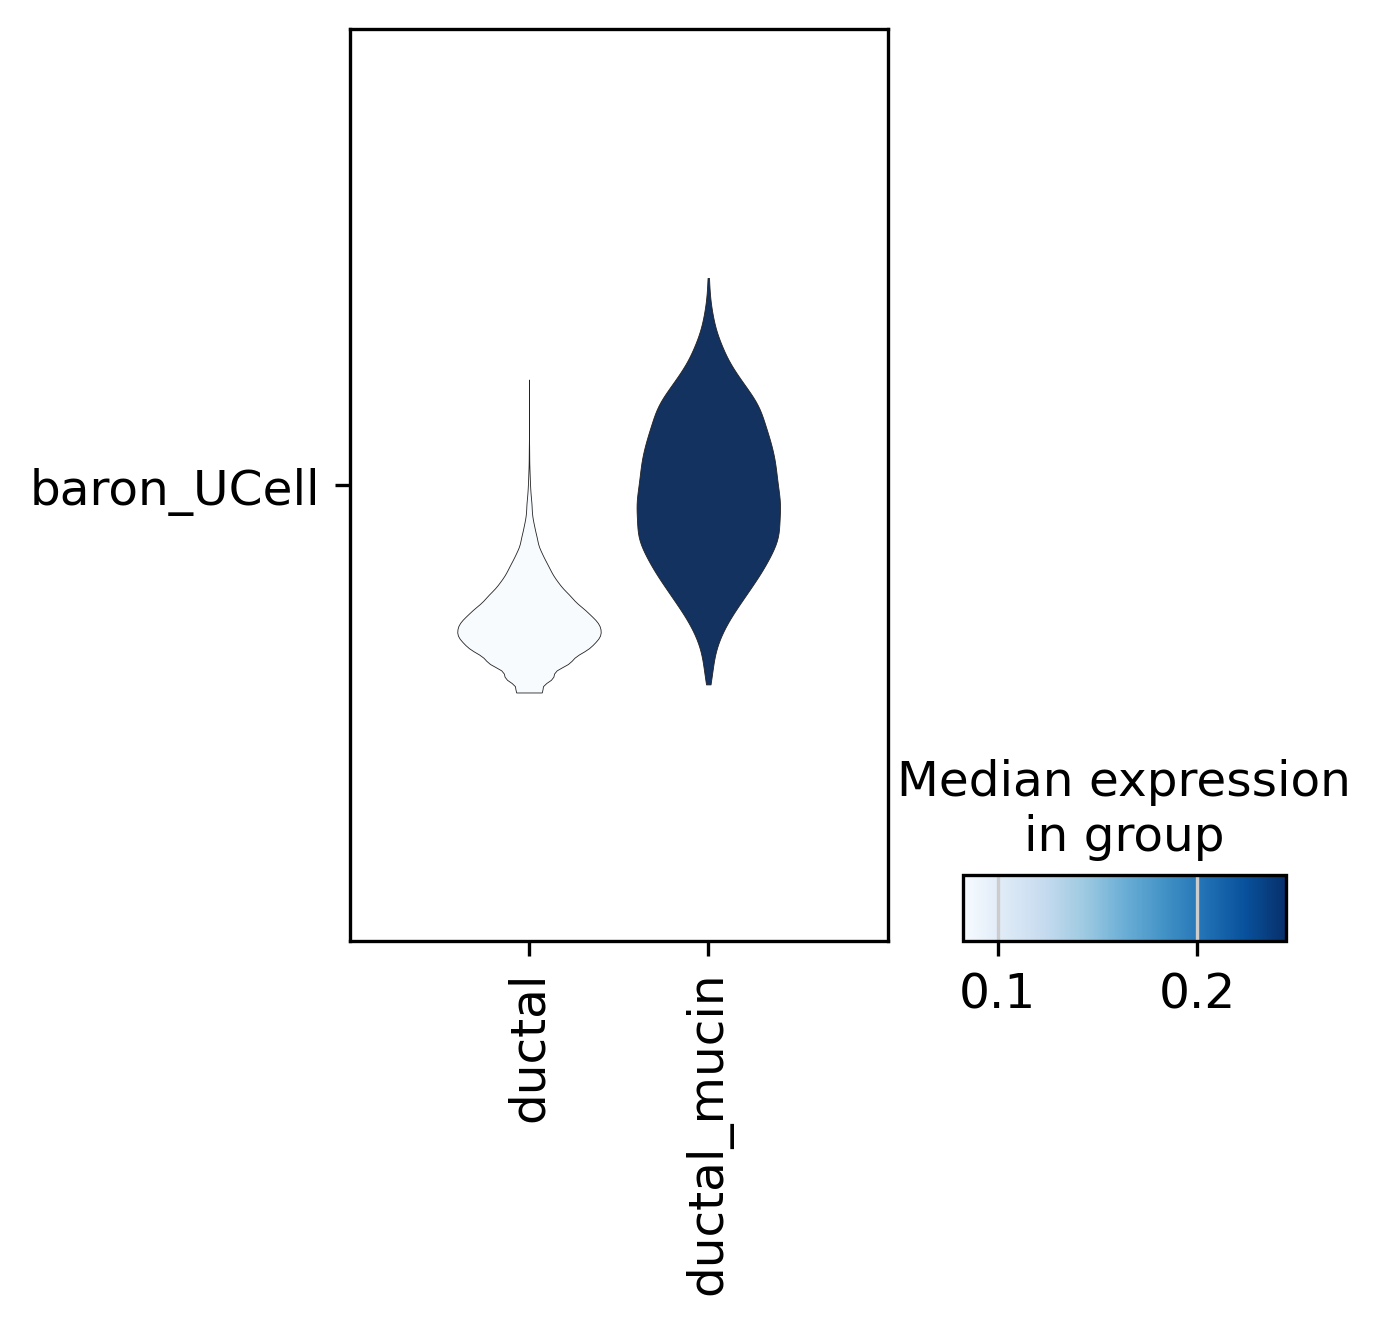

In [113]:
sc.pl.stacked_violin(adata_sub, var_names="baron_UCell", figsize=(4,4), groupby='manual_annotation', swap_axes= True, categories_order=["ductal", "ductal_mucin"])

In [115]:
sc.pl.stacked_violin(adata_sub, var_names=baron_subcluster_genes, figsize=(4,4), groupby='manual_annotation', swap_axes= True, categories_order=["ductal", "ductal_mucin"])

KeyError: "Could not find keys [np.str_('CALM4'), np.str_('CEACAM'), np.str_('CLDN'), np.str_('LF3'), np.str_('PDGFR'), np.str_('PMP3'), np.str_('SEN')] in columns of `adata.obs` or in adata.var_names."